# Gaussian basis functions
## Properties and integral generation

In this chapter we will develop code for symbolic generation of molecular integrals over Gaussian basis functions. The goal is automatically generate analytic formulas for all types of molecular integrals that are needed to perform quantum chemical calculations. Subsequently we will use automatic code generation in order to translate the analytic expressions into a generally usable code. 
This will be a first step that will provide us with key routines and enable us to implement a large variety of electronic structure methods (HF, CI, DFT, etc.)

We start with one-dimensional Cartesian Gaussians, derive recurrence relations and overlap expressions, and then use symbolic manipulation to generate reusable integral expressions for implementation. Our intention is not to develop a highly efficient generally applicable code but to understand key concepts and techniques and develop relatively easily understandable ''toy'' program.

## Cartesian Gaussian Functions

We begin by introducing one-dimensional Cartesian Gaussian functions and their relation to Hermite Gaussian functions. Both families appear throughout quantum chemistry because Gaussian-type basis functions make many molecular integrals analytically tractable. In particular, rewriting a Cartesian Gaussian as a finite linear combination of Hermite Gaussians is a central step in integral algorithms.

A one-dimensional Cartesian Gaussian of order $n$ is defined as

$$
g_n(x;\alpha,A_x)= (x-A_x)^n\, e^{-\alpha (x-A_x)^2}.
$$

Here, $n\in\mathbb{N}_0$ is a nonnegative integer, $A_x$ is the center, and $\alpha>0$ is the Gaussian exponent that controls the width (larger $\alpha$ means a more localized function).

In the first warm-up exercise we implement a small Python class for $g_n(x)$ and plot the functions for $n=1,\ldots,10$ at fixed $\alpha$ and $A_x$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [9]:
class Gaussian1D:
    def __init__(self, alpha: float, n: int = 0, Ax: float = 0.0):
        self.alpha = alpha
        self.n = n
        self.Ax = Ax
    def __call__(self, x: np.ndarray) -> np.ndarray:
        dx = x-self.Ax
        return np.power(dx, self.n)*np.exp(-self.alpha * dx**2)
    def plot(self, plot_range: np.ndarray = None, show: bool = True):
        if plot_range is None:
            plot_range = np.linspace(-10.0,10.0,100)
        plt.plot(plot_range, self(plot_range), lw = 2.0)
        plt.xlabel("x")
        plt.ylabel("f(x)")
        if show:
            plt.show()

An interesting feature of this class is the special method `__call__`. Defining `__call__` as a class member makes *instances* of the class callable, so that they can be called like ordinary functions. If `g = CartesianGaussian1D(n, alpha, A)`, then `g(x)` evaluates the Gaussian at the points `x` without requiring a separate method name such as `g.eval(x)`. In this way, the object stores the parameters $n$, $\alpha$, and $A_x$, while the call `g(x)` returns the numerical values of $g_n(x)$, which can be passed directly to plotting routines.

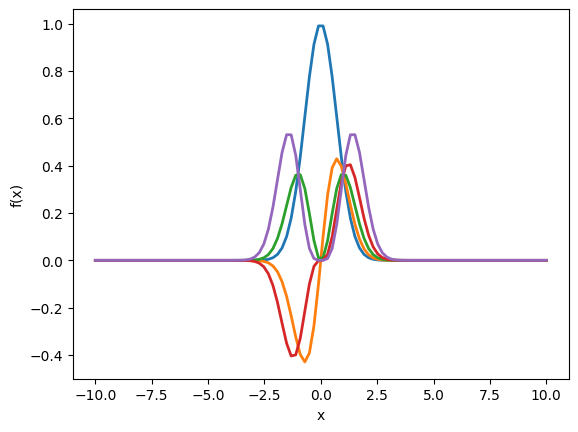

In [10]:
gaussians = [Gaussian1D(alpha = 1.0, n=i, Ax = 0.0) for i in range(5)]
gplots = [gfun.plot(show = False) for gfun in gaussians]

We can observe that with increasing order $n$ the maximum of the Gaussian functions moves outwards. Intuitively, the polynomial factor $(x-A_x)^n$ suppresses the function near the center $A_x$ and shifts the dominant weight to larger values, while the exponential term $e^{-\alpha(x-A_x)^2}$ still enforces normalizability. As a consequence, for a range of $n$-values such functions “cover” increasingly large portions of space and can therefore serve as a basis for representing arbitrary functions that vanish as $|x|\to\infty$. This is one of the reasons why such functions are popular as basis functions in the electronic structure calculations. 

## Overlap integrals between arbitrary order Gaussians

Since in almost all quantum-chemical calculations atom-centered basis functions represented by Cartesian Gaussians are used, it is necessary to derive analytic expressions for one- and two-electron integrals between such functions. The simplest of all one-electron integrals are overlap integrals between three-dimensional Gaussians that can be reduced to products of one-dimensional overlap integrals. We therefore begin with the analytic calculation of the overlap between two one-dimensional Gaussians centered at different positions. 

We define two $s$-type one-dimensional Cartesian Gaussians centered at $A_x$ and $B_x$,

$$
g_{0A}(x)=e^{-\alpha (x-A_x)^2},\qquad g_{0B}(x)=e^{-\beta (x-B_x)^2},
$$

with $\alpha>0$ and $\beta>0$. We wish to evaluate the overlap integral

$$
S_{00}=\int_{-\infty}^{+\infty} dx\, g_{0A}(x)\,g_{0B}(x)
      =\int_{-\infty}^{+\infty} dx\,\exp\!\Big(-\big[\alpha(x-A_x)^2+\beta(x-B_x)^2\big]\Big).
$$

To proceed we derive first the **Gaussian product theorem** by analyzing the quadratic exponent

$$
f(x)=\alpha(x-A_x)^2+\beta(x-B_x)^2.
$$

Since $f$ is a convex quadratic polynomial, its minimum is located at the zero of the first derivative,

$$
f'(x)=2\alpha(x-A_x)+2\beta(x-B_x),
$$

so that

$$
f'(P_x)=0 \quad\Rightarrow\quad P_x=\frac{\alpha A_x+\beta B_x}{\alpha+\beta}.
$$

The second derivative is constant,

$$
f''(x)=2(\alpha+\beta),
$$

and therefore the Taylor expansion about $x=P_x$ terminates exactly at second order:

$$
f(x)=f(P_x)+\frac{f''(P_x)}{2}(x-P_x)^2=f(P_x)+(\alpha+\beta)(x-P_x)^2.
$$

A short algebraic simplification gives the minimum value

$$
f(P_x)=\frac{\alpha\beta}{\alpha+\beta}(A_x-B_x)^2.
$$

Introducing the standard abbreviations $p=\alpha+\beta$ and $\mu=\alpha\beta/(\alpha+\beta)$, we obtain the Gaussian product theorem in the compact form

$$
e^{-\alpha(x-A_x)^2}\,e^{-\beta(x-B_x)^2}
=\exp\!\big(-\mu(A_x-B_x)^2\big)\,\exp\!\big(-p(x-P_x)^2\big).
$$

With this identity the overlap integral reduces to a shifted normalized Gaussian integral:

$$
S_{00}=\exp\!\big(-\mu(A_x-B_x)^2\big)\int_{-\infty}^{+\infty} dx\, e^{-p(x-P_x)^2}
      =\sqrt{\frac{\pi}{p}}\;\exp\!\big(-\mu(A_x-B_x)^2\big),
$$

or equivalently,

$$
S_{00}=\sqrt{\frac{\pi}{\alpha+\beta}}\;\exp\!\left(-\frac{\alpha\beta}{\alpha+\beta}(A_x-B_x)^2\right).
$$

We can verify this formula using symbolic integration with Sympy:

## Hermite-Gaussian functions

A **Hermite–Gaussian** of order $k$ is defined by

$$
\begin{aligned}
h_k(x)
&=\frac{\partial^k}{\partial A_x^k}\, g_{0A}(x)\\
&=\frac{\partial^k}{\partial A_x^k}\left[e^{-\alpha(x-A_x)^2}\right].
\end{aligned}
$$

where one formally calculates the derivative with respect to center parameter $A_x$. 
We symbolically compute couple of low-order Hermite–Gaussians and compare their form with the Cartesian Gaussian functions. 

x = sp.symbols('x', real = True)
Ax = sp.symbols('Ax', real = True)
alpha = sp.symbols('alpha', real = True, positive = True)

In [12]:
x, Ax = sp.symbols('x Ax', real = True)
alpha = sp.symbols('alpha', real = True, positive = True)

g0_A = sp.exp(-alpha*(x-Ax)**2)
def get_hermite_gaussian(k, g0_A):
    return sp.factor_terms(sp.diff(g0_A, (Ax, k)))

In [13]:
from IPython.display import display, Markdown

In [14]:
nmax = 11
hermite_gaussians = [get_hermite_gaussian(k, g0_A) for k in range(nmax)]
latex_rows = [f"$H_{k}(x) = {sp.latex(hg)}\n $" 
              for k, hg in enumerate(hermite_gaussians)]
markdown_output = "### Hermite-Gaussian Functions \n\n"+"\n\n".join(latex_rows)
display(Markdown(markdown_output))

### Hermite-Gaussian Functions 

$H_0(x) = e^{- \alpha \left(- Ax + x\right)^{2}}
 $

$H_1(x) = - 2 \alpha \left(Ax - x\right) e^{- \alpha \left(- Ax + x\right)^{2}}
 $

$H_2(x) = 2 \alpha \left(2 \alpha \left(Ax - x\right)^{2} - 1\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_3(x) = 4 \alpha^{2} \left(Ax - x\right) \left(- 2 \alpha \left(Ax - x\right)^{2} + 3\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_4(x) = 4 \alpha^{2} \left(4 \alpha^{2} \left(Ax - x\right)^{4} - 12 \alpha \left(Ax - x\right)^{2} + 3\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_5(x) = 8 \alpha^{3} \left(Ax - x\right) \left(- 4 \alpha^{2} \left(Ax - x\right)^{4} + 20 \alpha \left(Ax - x\right)^{2} - 15\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_6(x) = 8 \alpha^{3} \left(8 \alpha^{3} \left(Ax - x\right)^{6} - 60 \alpha^{2} \left(Ax - x\right)^{4} + 90 \alpha \left(Ax - x\right)^{2} - 15\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_7(x) = 16 \alpha^{4} \left(Ax - x\right) \left(- 8 \alpha^{3} \left(Ax - x\right)^{6} + 84 \alpha^{2} \left(Ax - x\right)^{4} - 210 \alpha \left(Ax - x\right)^{2} + 105\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_8(x) = 16 \alpha^{4} \left(16 \alpha^{4} \left(Ax - x\right)^{8} - 224 \alpha^{3} \left(Ax - x\right)^{6} + 840 \alpha^{2} \left(Ax - x\right)^{4} - 840 \alpha \left(Ax - x\right)^{2} + 105\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_9(x) = 32 \alpha^{5} \left(Ax - x\right) \left(- 16 \alpha^{4} \left(Ax - x\right)^{8} + 288 \alpha^{3} \left(Ax - x\right)^{6} - 1512 \alpha^{2} \left(Ax - x\right)^{4} + 2520 \alpha \left(Ax - x\right)^{2} - 945\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

$H_10(x) = 32 \alpha^{5} \left(32 \alpha^{5} \left(Ax - x\right)^{10} - 720 \alpha^{4} \left(Ax - x\right)^{8} + 5040 \alpha^{3} \left(Ax - x\right)^{6} - 12600 \alpha^{2} \left(Ax - x\right)^{4} + 9450 \alpha \left(Ax - x\right)^{2} - 945\right) e^{- \alpha \left(Ax - x\right)^{2}}
 $

As can be seen from the table generated using SymPy, 
Hermite–Gaussian functions have the general form of a polynomial 
(a Hermite polynomial) multiplying a Gaussian function. 
For a given $k$, the highest power of $x$ occurring in a Hermite–Gaussian is an $x^k$ term.


### Why are Hermite–Gaussian functions useful for the calculation of molecular integrals? 

If we look at the general overlap integral of the form

$$
\begin{aligned}
S_{mn}
&=\int_{-\infty}^{+\infty} dx\, g_{mA}(x)\, g_{nB}(x)\\
&=\int_{-\infty}^{+\infty} dx\,\left[e^{-\alpha\left(x-A_x\right)^2}\left(x-A_x\right)^m\right]
\left[e^{-\beta\left(x-B_x\right)^2}\left(x-B_x\right)^n\right],
\end{aligned}
$$

we see that the difficulty compared to $S_{00}$ is entirely due to the polynomial prefactors. Hermite–Gaussian functions are introduced precisely to handle these prefactors in a systematic way: they allow us to generate the required polynomial–Gaussian products through derivatives with respect to the center parameters, that can be interchanged with the integration with respect to the $x$-variable. This reduces ultimately all integrals with arbitrary polynomial factors to $S_{00}$.

Since the Cartesian Gaussians can be expanded in terms of Hermite–Gaussians as

$$
\begin{aligned}
g_{mA}(x)&=\sum_{k=0}^{m} C_{mk}\, h_{kA}(x),\\
g_{nB}(x)&=\sum_{l=0}^{n} C_{nl}\, h_{lB}(x),
\end{aligned}
$$

 the overlap integral can be expressed as

$$
S_{mn}=\sum_{k=0}^{m}\sum_{l=0}^{n} C_{mk}C_{nl}\int_{-\infty}^{+\infty} dx\, h_{kA}(x)\,h_{lB}(x).
$$

At first glance we have not gained anything since the expression looks rather more complicated. However, we can now exploit the definition of Hermite–Gaussians and interchange differentiation with respect to $A_x$ and $B_x$ with integration:

$$
\begin{aligned}
S_{mn}
&=\sum_{k=0}^{m}\sum_{l=0}^{n} C_{mk}C_{nl}\,
\frac{\partial^k}{\partial A_x^k}\frac{\partial^l}{\partial B_x^l}
\left[\int_{-\infty}^{+\infty} dx\, g_{0A}(x)\, g_{0B}(x)\right]\\
&=\sum_{k=0}^{m}\sum_{l=0}^{n} C_{mk}C_{nl}\,
\frac{\partial^k}{\partial A_x^k}\frac{\partial^l}{\partial B_x^l}
\left[\sqrt{\frac{\pi}{\alpha+\beta}}\, e^{-\frac{\alpha\beta}{\alpha+\beta}(A_x-B_x)^2}\right].
\end{aligned}
$$

This is a significant improvement! We can now generate an arbitrary overlap integral by differentiating the basic integral $S_{00}$ with respect to the nuclear coordinates. However, in order to proceed along these lines we need explicit expressions for the expansion coefficients $C_{mk}$. We will now derive relations that allow us to generate these coefficients recursively, which at the same time provides a proof that Hermite–Gaussians span the space of finite-order polynomial prefactors.


### RECURSIVE FORMULA FOR $C_{nk}$: 

We start from the assumption that an $(n+1)$-th order Cartesian Gaussian $g_{n+1}(x)=(x-A_x)^{n+1}e^{-\alpha(x-A_x)^2}$ can be expanded in Hermite–Gaussians of orders $0\le k\le n+1$ as

$$
g_{n+1}(x)=\sum_{k=0}^{n+1} C_k^{\,n+1}\, h_k(x).
$$


### Derivation of the recursive formula

Let us start by observing that $g_{n+1}(x)=(x-A_x)\,g_n(x)$, which is just the recursion for generating the Cartesian Gaussians. Since both $g_n$ and $g_{n+1}$ can be expanded in terms of Hermite–Gaussians we have the following identity:

$$
\begin{gathered}
g_{n+1}(x)=\sum_{k=0}^{n+1} C_k^{\,n+1}\,h_k(x),\\
g_n(x)=\sum_{k=0}^{n} C_k^{\,n}\,h_k(x),\\[2mm]
\Downarrow\qquad
\sum_{k=0}^{n+1} C_k^{\,n+1}\,h_k(x)=\sum_{k=0}^{n} C_k^{\,n}\,(x-A_x)\,h_k(x).
\end{gathered}
$$

We now need to simplify this expression and start by noting that, with $D\equiv\partial/\partial A_x$,

$$
\begin{aligned}
h_{k+1}(x)=D^{k+1} g_0(x)
&=D^k\!\left(D g_0(x)\right)\\
&=D^k\!\left(2\alpha(x-A_x)\, g_0(x)\right)\\
&=2\alpha\,D^k\!\left[(x-A_x)\, g_0(x)\right].
\end{aligned}
$$

We now apply the Leibniz rule:

$$
D^k(fg)=\sum_{l=0}^{k}\binom{k}{l}\,D^l f\,D^{k-l} g.
$$

$$
\begin{aligned}
h_{k+1}(x)
&=2\alpha\,D^k\!\left[(x-A_x)g_0(x)\right]\\
&=2\alpha\sum_{l=0}^{k}\binom{k}{l}\,D^l(x-A_x)\,D^{k-l}g_0(x)\\
&=2\alpha\left[(x-A_x)D^k g_0(x)-k\,D^{k-1}g_0(x)\right]\\
&=2\alpha(x-A_x)\,h_k(x)-2\alpha k\,h_{k-1}(x).
\end{aligned}
$$

From this relation we can eliminate $(x-A_x)h_k(x)$ and, by inserting it into the above expansion of $g_{n+1}(x)$, we may write

$$
\sum_{k=0}^{n+1} C_k^{\,n+1}\,h_k(x)
=\sum_{k=0}^{n} C_k^{\,n}\,(x-A_x)\,h_k(x)
=\sum_{k=0}^{n}\frac{C_k^{\,n}}{2\alpha}\,h_{k+1}(x)+\sum_{k=0}^{n}k\,C_k^{\,n}\,h_{k-1}(x).
$$

Now we simplify the sums by redefining the summation indices on the right-hand side:

$$
\begin{aligned}
\sum_{k=0}^{n}\frac{C_k^{\,n}}{2\alpha}\,h_{k+1}
&=\sum_{k=1}^{n+1}\frac{C_{k-1}^{\,n}}{2\alpha}\,h_k,\\
\sum_{k=0}^{n}k\,C_k^{\,n}\,h_{k-1}
&=\sum_{k=0}^{n-1}(k+1)\,C_{k+1}^{\,n}\,h_k.
\end{aligned}
$$

The identity thus becomes

$$
\sum_{k=0}^{n+1} C_k^{\,n+1}\,h_k
=\sum_{k=1}^{n+1}\frac{C_{k-1}^{\,n}}{2\alpha}\,h_k
+\sum_{k=0}^{n-1}(k+1)\,C_{k+1}^{\,n}\,h_k.
$$

Finally, we rewrite the sums such that they start and end at the same indices:

$$
\begin{aligned}
C_0^{\,n+1}h_0+C_n^{\,n+1}h_n+C_{n+1}^{\,n+1}h_{n+1}+\sum_{k=1}^{n-1}C_k^{\,n+1}h_k
&=C_1^{\,n}h_0+\frac{C_{n-1}^{\,n}}{2\alpha}h_n+\frac{C_n^{\,n}}{2\alpha}h_{n+1}\\
&\quad+\sum_{k=1}^{n-1}\left[\frac{C_{k-1}^{\,n}}{2\alpha}+(k+1)C_{k+1}^{\,n}\right]h_k.
\end{aligned}
$$



By comparing the two sums we obtain
$$
C_k^{\,n+1}=\frac{1}{2\alpha}\,C_{k-1}^{\,n}+(k+1)\,C_{k+1}^{\,n}.
$$

Moreover, we have the following relations:
$$
\begin{array}{ll}
C_0^{\,n+1}=C_1^{\,n}, & C_0^{\,0}=1,\\ \\
C_{n+1}^{\,n+1}=\dfrac{C_n^{\,n}}{2\alpha}, & \\ \\
C_n^{\,n+1}=\dfrac{C_{n-1}^{\,n}}{2\alpha}. &
\end{array}
$$

The calculation of the expansion coefficients can now be implemented as a recursive function in Python.

In [15]:
from functools import lru_cache
@lru_cache(maxsize=None)
def get_ckn(k: int, n: int, p):
    """Coefficient C_k^n in the Cartesian-to-Hermite expansion."""
    if k < 0 or k > n:
        return sp.Integer(0)
    if n == 0:
        return sp.Integer(1) if k == 0 else sp.Integer(0)
    return get_ckn(k - 1, n - 1, p) / (2 * p) + (k + 1) * get_ckn(k + 1, n - 1, p)

We check that the recursion provides the correct expansion by explicitly calculating the lowest few Cartesian Gaussians expressed as a sum over Hermite_Gaussians.

In [16]:
nmax = 6
for n in range(nmax + 1):
    g = 0
    for k in range(0, n + 1):
        g = g + get_ckn(k, n, alpha) * hermite_gaussians[k]
    g = sp.simplify(g)
    print(f"g_{n} = {g}")


g_0 = exp(-alpha*(Ax - x)**2)
g_1 = (-Ax + x)*exp(-alpha*(Ax - x)**2)
g_2 = (Ax - x)**2*exp(-alpha*(Ax - x)**2)
g_3 = -Ax*(Ax - x)**2*exp(-alpha*(Ax - x)**2) + x*(Ax - x)**2*exp(-alpha*(Ax - x)**2)
g_4 = (Ax - x)**4*exp(-alpha*(Ax - x)**2)
g_5 = -Ax*(Ax - x)**4*exp(-alpha*(Ax - x)**2) + x*(Ax - x)**4*exp(-alpha*(Ax - x)**2)
g_6 = (Ax - x)**6*exp(-alpha*(Ax - x)**2)
